# Final Evaluation Summary

This notebook explains the final evaluation result for the ABSA project in simple terms.

It answers the teacher's questions:

- What is F1-score?
- Why is F1-score suitable?
- How is F1-score used in this project?
- What is the final F1-score result?
- Is the result good or not?

## 1. What F1-score Means

**Precision** means: when the model predicts a label, how often is it correct?

**Recall** means: from all true examples of a label, how many did the model find?

**F1-score** combines precision and recall into one balanced score.

In simple words: F1-score is useful because it checks whether the model is both correct and able to find the right labels.

## 2. Why F1-score Is Suitable

The dataset is imbalanced. Most aspect labels are `Unknown` because one review usually does not mention all four aspects.

If we only use accuracy, the result can be misleading. A model can get high accuracy by predicting `Unknown` too often.

Therefore, this project uses **macro F1** and **weighted F1**.

- **Macro F1** treats Positive, Negative, and Unknown equally.
- **Weighted F1** considers how many examples each label has.

For this project, macro F1 is very important because it shows whether the model handles all labels fairly.

In [1]:
from pathlib import Path
import json
from statistics import mean

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "backends").exists():
    PROJECT_ROOT = Path.cwd().parents[1]

TRADITIONAL_REPORT = PROJECT_ROOT / "backends" / "traditional_ml" / "training_report.json"
BERT_REPORT = PROJECT_ROOT / "backends" / "deep_learning" / "bert_training_report.json"

traditional_report = json.loads(TRADITIONAL_REPORT.read_text(encoding="utf-8"))
bert_report = json.loads(BERT_REPORT.read_text(encoding="utf-8"))

def print_table(headers, rows):
    widths = [len(str(header)) for header in headers]
    for row in rows:
        widths = [max(width, len(str(value))) for width, value in zip(widths, row)]
    fmt = "  ".join("{:<" + str(width) + "}" for width in widths)
    print(fmt.format(*headers))
    print(fmt.format(*["-" * width for width in widths]))
    for row in rows:
        print(fmt.format(*row))

print("Loaded evaluation reports successfully.")

Loaded evaluation reports successfully.


## 3. Traditional Machine Learning Result

The traditional ML model is evaluated separately for each aspect because it trains one classifier per aspect.

In [2]:
traditional_rows = []
for aspect, metrics in traditional_report["metrics"].items():
    traditional_rows.append([
        aspect,
        f"{metrics['accuracy']:.4f}",
        f"{metrics['macro_f1']:.4f}",
        f"{metrics['weighted_f1']:.4f}",
    ])

print_table(["Aspect", "Accuracy", "Macro F1", "Weighted F1"], traditional_rows)

Aspect                         Accuracy  Macro F1  Weighted F1
-----------------------------  --------  --------  -----------
Food                           0.8210    0.6686    0.8105     
Service                        0.8555    0.5748    0.8310     
Price                          0.9294    0.5904    0.9095     
Eating Environment / Ambiance  0.8949    0.5130    0.8729     


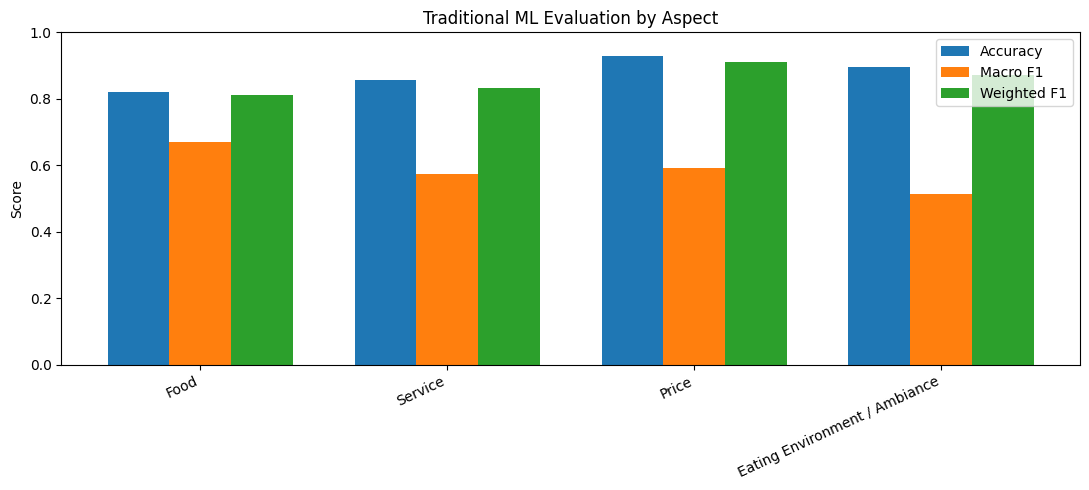

In [3]:
aspects = [row[0] for row in traditional_rows]
accuracy = [float(row[1]) for row in traditional_rows]
macro_f1 = [float(row[2]) for row in traditional_rows]
weighted_f1 = [float(row[3]) for row in traditional_rows]

x = range(len(aspects))
width = 0.25
plt.figure(figsize=(11, 5))
plt.bar([i - width for i in x], accuracy, width=width, label="Accuracy")
plt.bar(list(x), macro_f1, width=width, label="Macro F1")
plt.bar([i + width for i in x], weighted_f1, width=width, label="Weighted F1")
plt.xticks(list(x), aspects, rotation=25, ha="right")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Traditional ML Evaluation by Aspect")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Deep Learning / DeBERTa Result

The deep learning model uses review-aspect pairs. For each review, it checks Food, Service, Price, and Eating Environment / Ambiance separately.

In [4]:
bert_metrics = bert_report["test_metrics"]
bert_rows = [
    ["Accuracy", f"{bert_metrics['accuracy']:.4f}"],
    ["Macro Precision", f"{bert_metrics['macro_precision']:.4f}"],
    ["Macro Recall", f"{bert_metrics['macro_recall']:.4f}"],
    ["Macro F1", f"{bert_metrics['macro_f1']:.4f}"],
    ["Weighted F1", f"{bert_metrics['weighted_f1']:.4f}"],
]

print_table(["Metric", "Score"], bert_rows)

Metric           Score 
---------------  ------
Accuracy         0.9197
Macro Precision  0.8352
Macro Recall     0.8185
Macro F1         0.8205
Weighted F1      0.9206


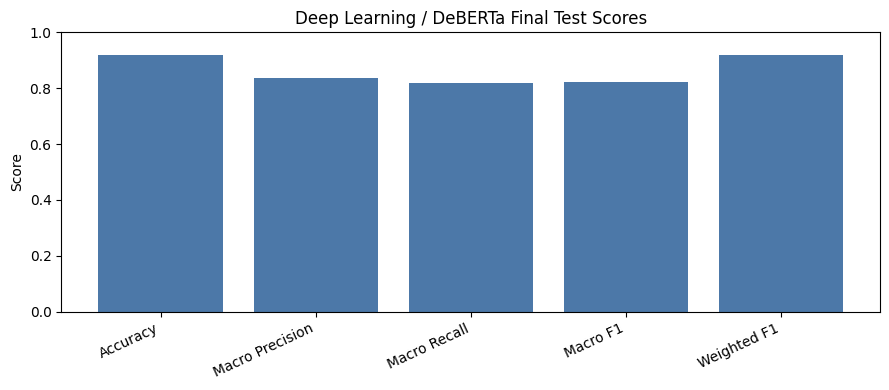

In [5]:
metric_names = [row[0] for row in bert_rows]
metric_scores = [float(row[1]) for row in bert_rows]

plt.figure(figsize=(9, 4))
plt.bar(metric_names, metric_scores, color="#4C78A8")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Deep Learning / DeBERTa Final Test Scores")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 5. Per-label F1 Result

This shows how well the deep learning model performs on Positive, Negative, and Unknown.

Negative is harder because it has fewer examples in the dataset.

In [6]:
per_label_rows = []
for label, metrics in bert_report["per_label"].items():
    per_label_rows.append([
        label,
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['f1']:.4f}",
        str(metrics["support"]),
    ])

print_table(["Label", "Precision", "Recall", "F1", "Support"], per_label_rows)

Label     Precision  Recall  F1      Support
--------  ---------  ------  ------  -------
Positive  0.7135     0.8671  0.7829  158    
Negative  0.8269     0.6418  0.7227  67     
Unknown   0.9652     0.9467  0.9559  995    


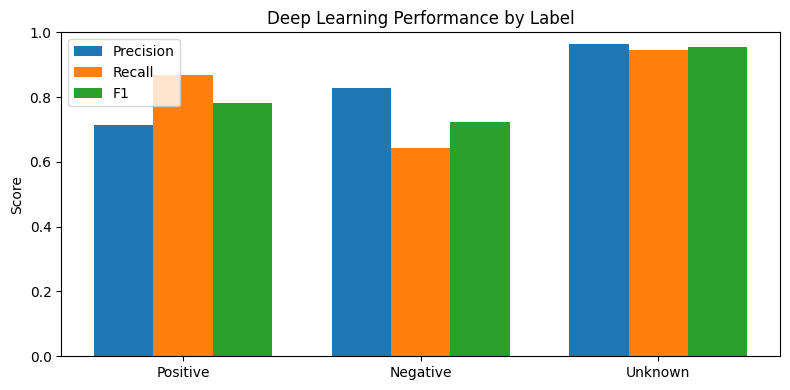

In [7]:
labels = [row[0] for row in per_label_rows]
precision = [float(row[1]) for row in per_label_rows]
recall = [float(row[2]) for row in per_label_rows]
f1 = [float(row[3]) for row in per_label_rows]

x = range(len(labels))
width = 0.25
plt.figure(figsize=(8, 4))
plt.bar([i - width for i in x], precision, width=width, label="Precision")
plt.bar(list(x), recall, width=width, label="Recall")
plt.bar([i + width for i in x], f1, width=width, label="F1")
plt.xticks(list(x), labels)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Deep Learning Performance by Label")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Final Meaning

The deep learning model achieved:

- Accuracy: **0.9197**
- Macro F1: **0.8205**
- Weighted F1: **0.9206**

This is a good result for the project. It means the model performs well overall and has a strong macro F1 score.

The model is not perfect. The Negative label is harder than Unknown because there are fewer Negative examples. This is why future work should add more Positive and Negative examples, especially Negative examples.